In [54]:
#import data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [55]:
#Load data and take a peak(10 rows)
df = pd.read_csv('/Users/gavalencia/Desktop/insurance_data/train.csv')
INR_TO_USD = 83   # roughly ₹83 = $1 — set to whatever rate you want to cite

df["Annual_Premium"] = (df["Annual_Premium"] / INR_TO_USD).round(2)
df.head(10)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,487.40,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,404.05,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,461.37,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,344.81,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,331.28,152.0,39,0
5,6,Female,24,1,33.0,0,< 1 Year,Yes,31.69,160.0,176,0
6,7,Male,23,1,11.0,0,< 1 Year,Yes,281.53,152.0,249,0
7,8,Female,56,1,28.0,0,1-2 Year,Yes,385.92,26.0,72,1
8,9,Female,24,1,3.0,1,< 1 Year,No,332.76,152.0,28,0
9,10,Female,32,1,6.0,1,< 1 Year,No,346.64,152.0,80,0


In [56]:
#How many rows and columns in the data?
print('Shape: ', df.shape)

Shape:  (381109, 12)


Response
0    334399
1     46710
Name: count, dtype: int64
Response
0    0.877437
1    0.122563
Name: proportion, dtype: float64


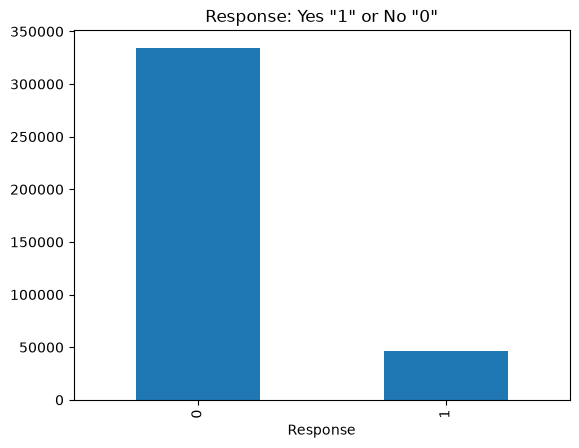

In [57]:
#In the Dataset how many rows are there with column=response where 0 or 1
#Same thing but normalize given values, how much of the pie do they make up
#Still same beginning, but 'plot' allows for some visualizations, in this case the kind = bar and the title = blah blah blah
#plt.show() is great for when using in IDLE or terminal, pops up seperate GUI with the visual, also good for getting rid of matplot text
print(df['Response'].value_counts())
print(df['Response'].value_counts(normalize=True))

df['Response'].value_counts().plot(kind='bar', title='Response: Yes "1" or No "0"')
plt.show()


Text(0.5, 1.0, 'Response Rate by Vehicle Damage')

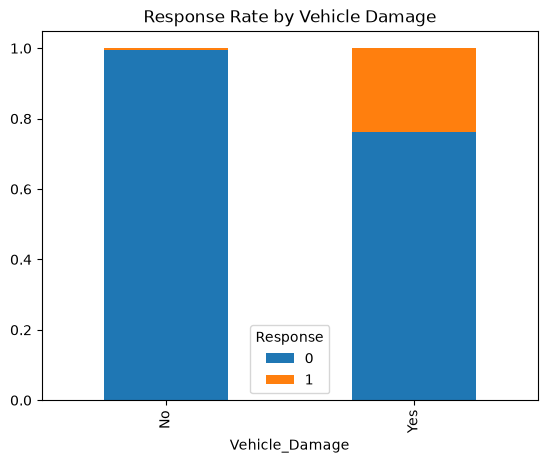

In [58]:
#Here we are going to show the relationship between vehicledamage and response using pandas crosstab function
#We then normalize(0-1) by row=index, this is needed to make comparing easier
pd.crosstab(df['Vehicle_Damage'], df['Response'], normalize='index').plot(kind='bar', stacked='True')
plt.title('Response Rate by Vehicle Damage')

In [59]:
#Keep only numeric columns, xorrelation of every column
#Basically cnumber further from one is more strongly correlated... sign is just direction   
df.select_dtypes('number').corr()['Response'].sort_values(ascending=False)

Response                1.000000
Age                     0.111147
Annual_Premium          0.022575
Region_Code             0.010570
Driving_License         0.010155
Vintage                -0.001050
id                     -0.001368
Policy_Sales_Channel   -0.139042
Previously_Insured     -0.341170
Name: Response, dtype: float64

In [60]:
#Drop ID column and change male and female to 0 and 1
#Change vehicle damage from YES/NO to 0 and 1
#Make vehicle age Ordinal... this way they keep their natural order
#Show first 10 rows of the new cleaned data
df_model = df.drop(columns=['id'])
df_model['Gender']=df_model['Gender'].map({'Male':1,'Female':0})
df_model['Vehicle_Damage']=df_model['Vehicle_Damage'].map({'Yes':1, 'No':0})
df_model["Vehicle_Age"] = df_model["Vehicle_Age"].map({"< 1 Year": 0, "1-2 Year": 1, "> 2 Years": 2})
df_model.head(10)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,44,1,28.0,0,2,1,487.40,26.0,217,1
1,1,76,1,3.0,0,1,0,404.05,26.0,183,0
2,1,47,1,28.0,0,2,1,461.37,26.0,27,1
3,1,21,1,11.0,1,0,0,344.81,152.0,203,0
4,0,29,1,41.0,1,0,0,331.28,152.0,39,0
5,0,24,1,33.0,0,0,1,31.69,160.0,176,0
6,1,23,1,11.0,0,0,1,281.53,152.0,249,0
7,0,56,1,28.0,0,1,1,385.92,26.0,72,1
8,0,24,1,3.0,1,0,0,332.76,152.0,28,0
9,0,32,1,6.0,1,0,0,346.64,152.0,80,0


In [61]:
# x features everything except for target, y the target we are predicting
# split the data into train and test, 80% train 20% test
# Stratify keeps the same class ratio as full data in both train and test (12%, 88%)
# Random state to lock shuffle in place between runs
x = df_model.drop(columns=['Response'])
y = df_model['Response']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

print(x_train.shape, x_test.shape)

(304887, 10) (76222, 10)


In [62]:
#Once model and scoring tools are imported, create model(let run up to 1000 steps to find a solution, make rare yes count more)
#Train on training data
#predict prob od yes for each row
#ROC_AUC - 0.83 good
#False yes = cheap, False no = expensive
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(x_train, y_train)

y_pred = logreg.predict(x_test)
y_prob = logreg.predict_proba(x_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


ROC-AUC: 0.8344
[[39598 27282]
 [  216  9126]]
              precision    recall  f1-score   support

           0       0.99      0.59      0.74     66880
           1       0.25      0.98      0.40      9342

    accuracy                           0.64     76222
   macro avg       0.62      0.78      0.57     76222
weighted avg       0.90      0.64      0.70     76222



/Users/gavalencia/miniconda3/envs/ads502/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
#import RandomForest
#200 tree, balance "yes" values, use all CPU cores, reproducible results
#probability of Yes per row, hard cutoff yes or no

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=42)
rf.fit(x_train, y_train)

rf_prob = rf.predict_proba(x_test)[:, 1]
rf_pred = rf.predict(x_test)

print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

ROC-AUC: 0.836
[[58962  7918]
 [ 5372  3970]]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     66880
           1       0.33      0.42      0.37      9342

    accuracy                           0.83     76222
   macro avg       0.63      0.65      0.64     76222
weighted avg       0.85      0.83      0.83     76222



Vehicle_Damage          0.195702
Vintage                 0.193461
Annual_Premium          0.169835
Previously_Insured      0.140622
Age                     0.119502
Region_Code             0.083188
Policy_Sales_Channel    0.059067
Vehicle_Age             0.028900
Gender                  0.009073
Driving_License         0.000649
dtype: float64


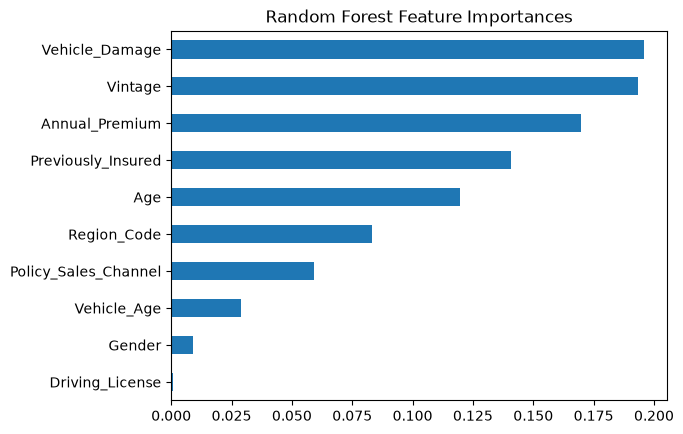

In [64]:
# Feauture importance has the forest report a score for each feauture(how much did it help the tree make a decision)
# Attach each score to its column name
# rank most to least important
# barh = horizontal bar chart(Better for feature names), invert = flip y axis so most important features first
#render
importances = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
print(importances)

importances.plot(kind="barh", title="Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()

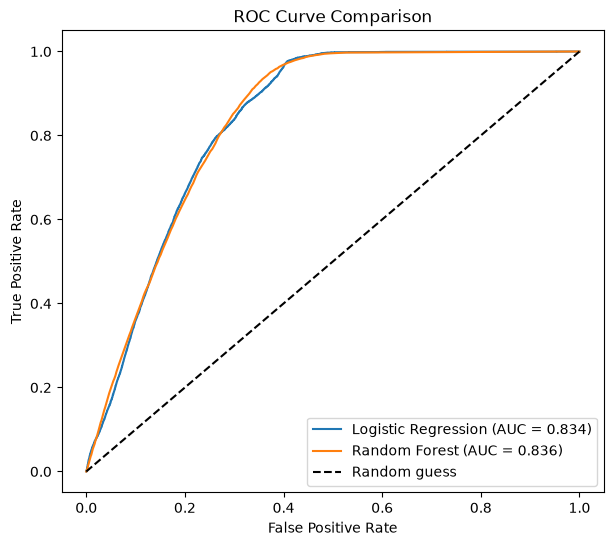

In [65]:
# import roc
#plot AUC ROC for regression and random forest, perform pretty similar
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

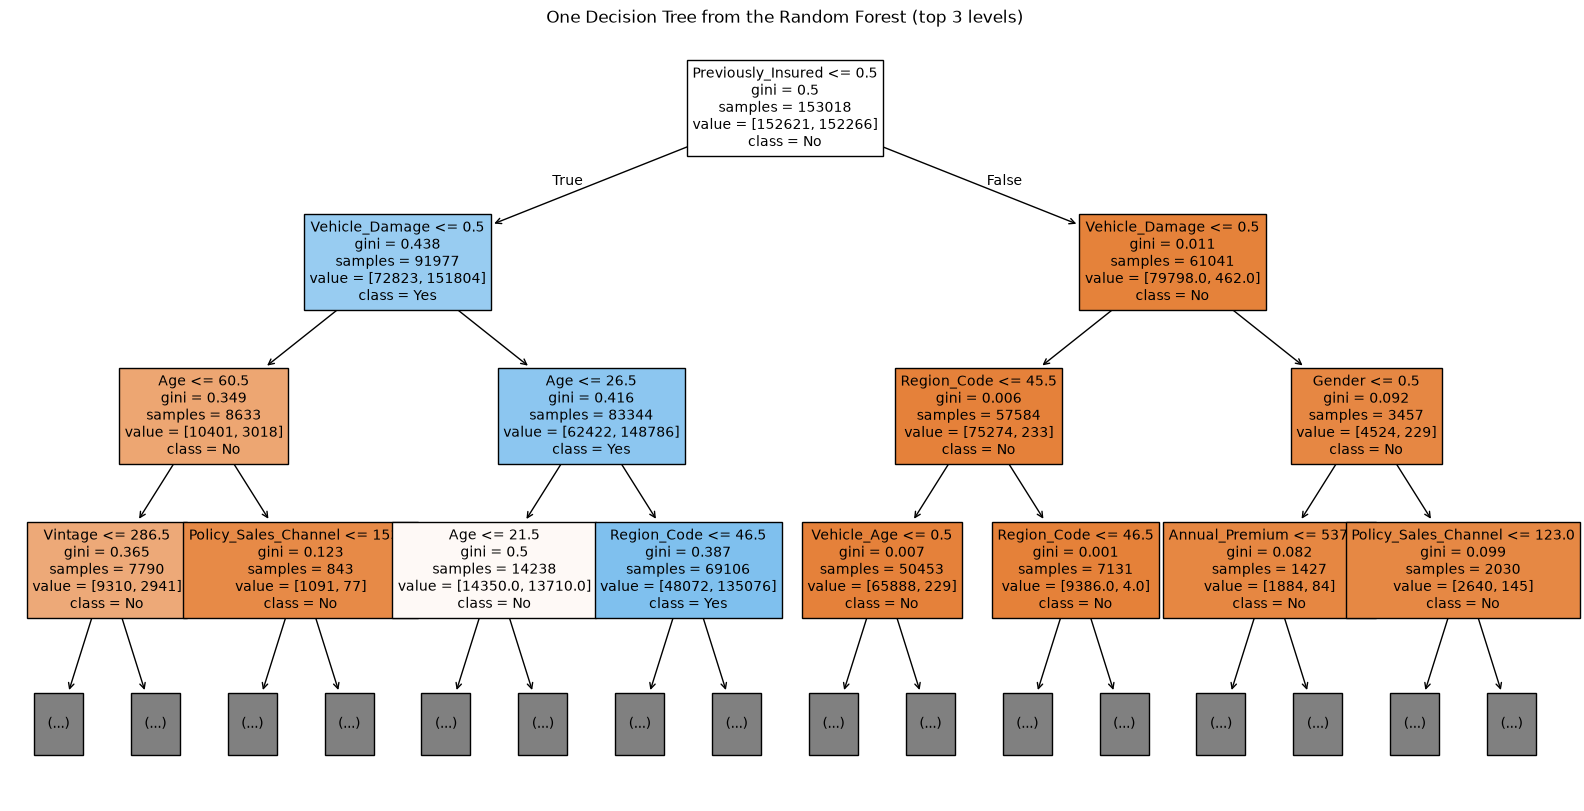

In [66]:
# Here we are visualiazing three layers of our random forest

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    rf.estimators_[0],
    feature_names=x.columns,
    class_names=["No", "Yes"],
    filled=True, max_depth=3, fontsize=10
)
plt.title("One Decision Tree from the Random Forest (top 3 levels)")
plt.show()

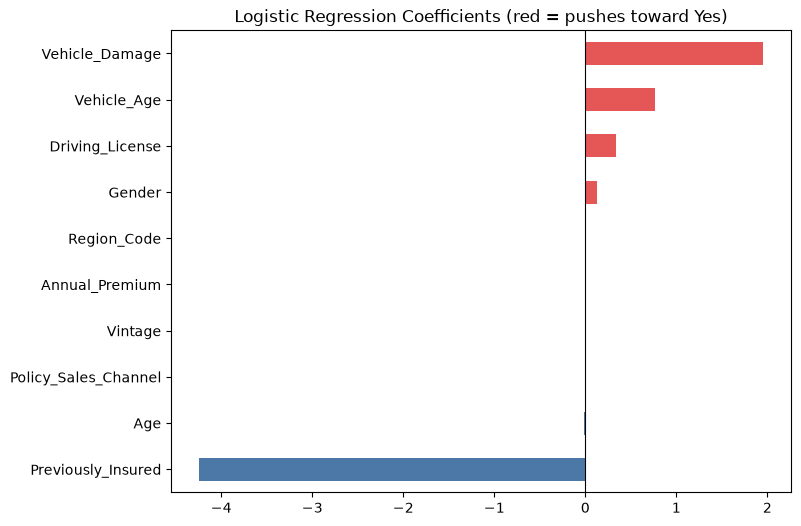

In [67]:
# Positie pushes toward yes, negative pushes toward no
# Order values low to high
#horizinatal bar, easier to read columns
# Color for said charts
# Vertical line at 0

coefs = pd.Series(logreg.coef_[0], index=x.columns).sort_values()

coefs.plot(kind="barh", figsize=(8, 6), color=(coefs > 0).map({True: "#e45756", False: "#4c78a8"}))
plt.title("Logistic Regression Coefficients (red = pushes toward Yes)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

In [ ]:
# Import model and scoring
# Create model, 300 trees, shallow(5), how much correction tree to tree
# Unlike forest each new tree is built in sequence, new trees fix previous mistakes
# Probility of yes... hard cutoff

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

gb = GradientBoostingClassifier(n_estimators=300, max_depth=5,
                                learning_rate=0.1, random_state=42)
gb.fit(x_train, y_train)

gb_prob = gb.predict_proba(x_test)[:, 1]
gb_pred = gb.predict(x_test)

print("ROC-AUC:", round(roc_auc_score(y_test, gb_prob), 4))
print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))



ROC-AUC: 0.8578
[[66666   214]
 [ 9162   180]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.46      0.02      0.04      9342

    accuracy                           0.88     76222
   macro avg       0.67      0.51      0.49     76222
weighted avg       0.83      0.88      0.82     76222



In [ ]:
# Same as last GBC, had good ROC-AUC -> 0.8578
# But, recall on Yes = 0.02, caught 180 of 9,342
# No class weight... predicted almost everyone "no"
# Changoing threshold to 0.15 chnages that for the better
#improves recall drastically... precision is worth but is less costly that not getting yes correct

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

gb = GradientBoostingClassifier(n_estimators=300, max_depth=5,
                                learning_rate=0.1, random_state=42)
gb.fit(x_train, y_train)

gb_prob = gb.predict_proba(x_test)[:, 1]
gb_pred = (gb_prob >= 0.15).astype(int)


print("ROC-AUC:", round(roc_auc_score(y_test, gb_prob), 4))
print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

ROC-AUC: 0.8578
[[47487 19393]
 [ 1079  8263]]
              precision    recall  f1-score   support

           0       0.98      0.71      0.82     66880
           1       0.30      0.88      0.45      9342

    accuracy                           0.73     76222
   macro avg       0.64      0.80      0.63     76222
weighted avg       0.89      0.73      0.78     76222



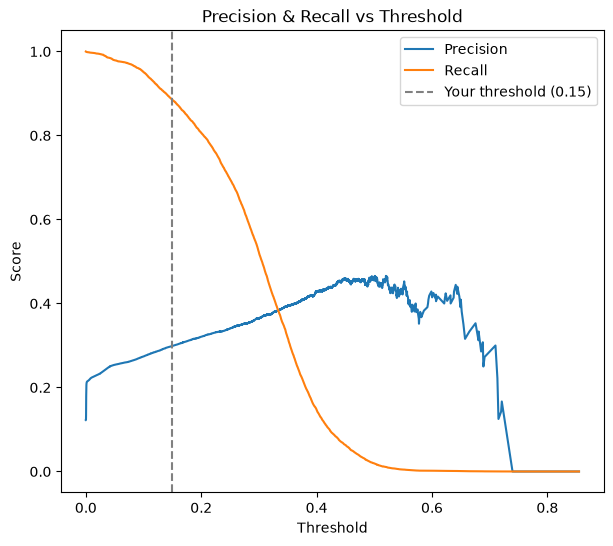

In [ ]:
# We value recall more as we care about buyers
# If we cared about not wasting contacts go right
# Equilibrium is only best if they matter the same

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

prec, rec, thresholds = precision_recall_curve(y_test, gb_prob)

plt.figure(figsize=(7, 6))
plt.plot(thresholds, prec[:-1], label="Precision")
plt.plot(thresholds, rec[:-1], label="Recall")
plt.axvline(0.15, color="gray", linestyle="--", label="Your threshold (0.15)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.show()


In [ ]:
# Hot encoded region code and policy sales channel
# Logistic regression is linear so it helped here, it assumes bigger number = stronger effect
# trees don't assume order doe not really affect

df_model = df.drop(columns=["id"])
df_model["Gender"] = df_model["Gender"].map({"Male": 1, "Female": 0})
df_model["Vehicle_Damage"] = df_model["Vehicle_Damage"].map({"Yes": 1, "No": 0})
df_model["Vehicle_Age"] = df_model["Vehicle_Age"].map({"< 1 Year": 0, "1-2 Year": 1, "> 2 Years": 2})

# one-hot encode the true categoricals
df_model = pd.get_dummies(df_model, columns=["Region_Code", "Policy_Sales_Channel"])

df_model.head()


,Gender,Age,Driving_License,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Vintage,Response,Region_Code_0.0,...,Policy_Sales_Channel_152.0,Policy_Sales_Channel_153.0,Policy_Sales_Channel_154.0,Policy_Sales_Channel_155.0,Policy_Sales_Channel_156.0,Policy_Sales_Channel_157.0,Policy_Sales_Channel_158.0,Policy_Sales_Channel_159.0,Policy_Sales_Channel_160.0,Policy_Sales_Channel_163.0
0,1,44,1,0,2,1,487.40,217,1,False,...,False,False,False,False,False,False,False,False,False,False
1,1,76,1,0,1,0,404.05,183,0,False,...,False,False,False,False,False,False,False,False,False,False
2,1,47,1,0,2,1,461.37,27,1,False,...,False,False,False,False,False,False,False,False,False,False
3,1,21,1,1,0,0,344.81,203,0,False,...,True,False,False,False,False,False,False,False,False,False
4,0,29,1,1,0,0,331.28,39,0,False,...,True,False,False,False,False,False,False,False,False,False


In [74]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

x = df_model.drop(columns=["Response"])
y = df_model["Response"]
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42)

In [75]:
# --- Logistic Regression ---
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(x_train, y_train)
lr_prob = logreg.predict_proba(x_test)[:, 1]
print("LogReg ROC-AUC:", round(roc_auc_score(y_test, lr_prob), 4))

LogReg ROC-AUC: 0.8495


/Users/gavalencia/miniconda3/envs/ads502/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [76]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                            n_jobs=-1, random_state=42)
rf.fit(x_train, y_train)
rf_prob = rf.predict_proba(x_test)[:, 1]
print("RF ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))


RF ROC-AUC: 0.8348


In [77]:
# --- Gradient Boosting (tuned threshold) ---
gb = GradientBoostingClassifier(n_estimators=300, max_depth=5,
                                learning_rate=0.1, random_state=42)
gb.fit(x_train, y_train)
gb_prob = gb.predict_proba(x_test)[:, 1]
gb_pred = (gb_prob >= 0.15).astype(int)
print("GB ROC-AUC:", round(roc_auc_score(y_test, gb_prob), 4))
print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

GB ROC-AUC: 0.8579
[[47404 19476]
 [ 1072  8270]]
              precision    recall  f1-score   support

           0       0.98      0.71      0.82     66880
           1       0.30      0.89      0.45      9342

    accuracy                           0.73     76222
   macro avg       0.64      0.80      0.63     76222
weighted avg       0.89      0.73      0.78     76222

